In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries are working successfully!")

All libraries are working successfully!


In [2]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)


Dataset loaded successfully!
Shape of dataset: (395, 33)


In [3]:
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print(df.columns.tolist())


['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [6]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [10]:
df['G3'].describe()


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [11]:
df['G3'].value_counts().sort_index()


G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

Task was destroyed but it is pending!
task: <Task pending name='Task-87' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Jyoti\AppData\Roaming\Python\Python314\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-88' coro=<Kernel.shell_main() running at C:\Users\Jyoti\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Jyoti\AppData\Roaming\Python\Python314\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Jyoti\AppData\Roaming\Python\Python314\site-packages\pandas\core\internals\managers.py:2014: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def __init__(
Task was destroyed but it is pending!
task: <Task pending name='Task-88' coro=<Kernel.shell_main() running at C:\Users\Jyoti\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is

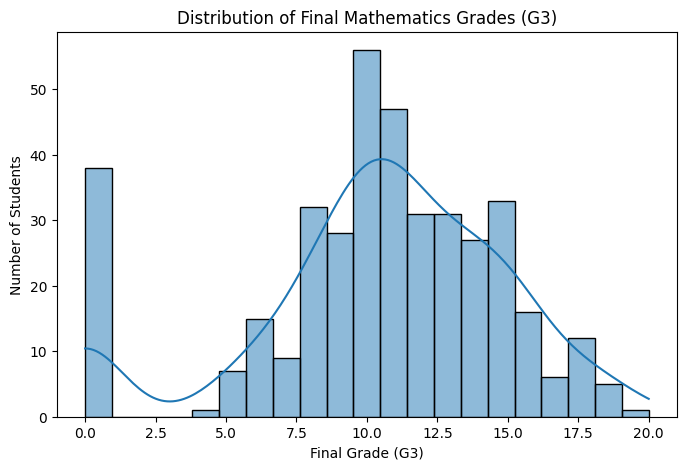

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['G3'], bins=21, kde=True)

plt.title('Distribution of Final Mathematics Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.show()

In [1]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='G1', y='G3')

plt.title('G1 vs Final Grade (G3)')
plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.show()


NameError: name 'plt' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded!")

Libraries loaded!


In [3]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (395, 33)


In [4]:
print(df['G3'].describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


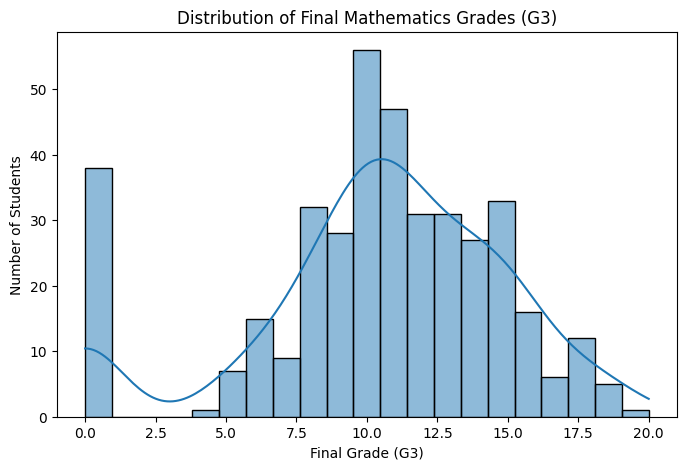

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df['G3'], bins=21, kde=True)

plt.title('Distribution of Final Mathematics Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.show()

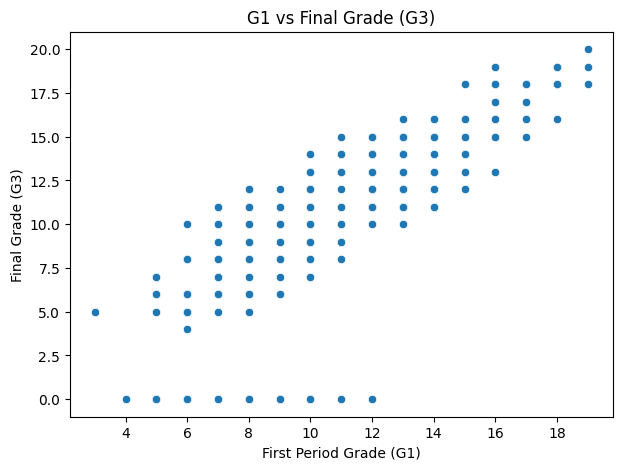

In [6]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='G1', y='G3')

plt.title('G1 vs Final Grade (G3)')
plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.show()

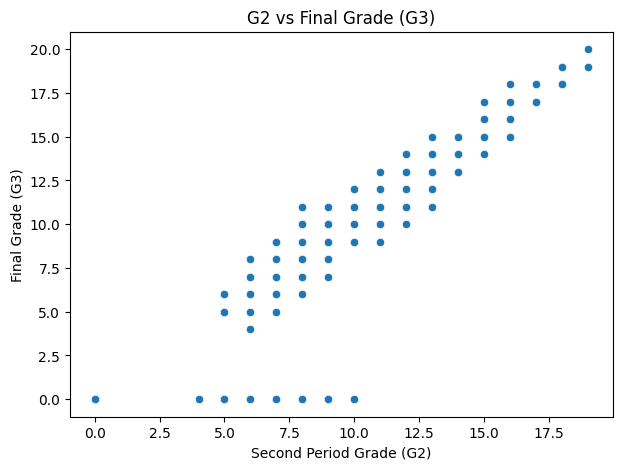

In [7]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='G2', y='G3')

plt.title('G2 vs Final Grade (G3)')
plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade (G3)')
plt.show()

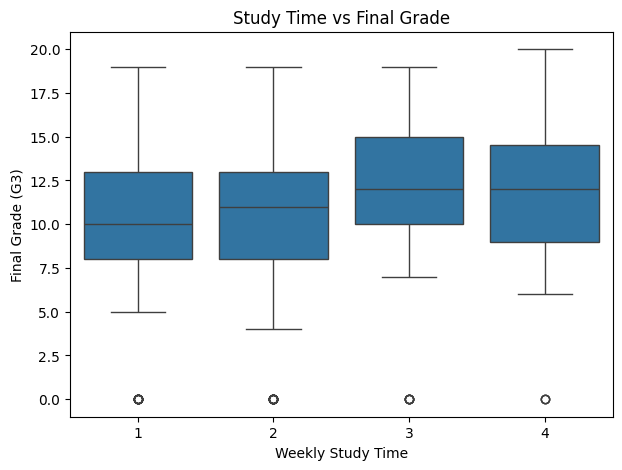

In [8]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='studytime', y='G3')

plt.title('Study Time vs Final Grade')
plt.xlabel('Weekly Study Time')
plt.ylabel('Final Grade (G3)')
plt.show()

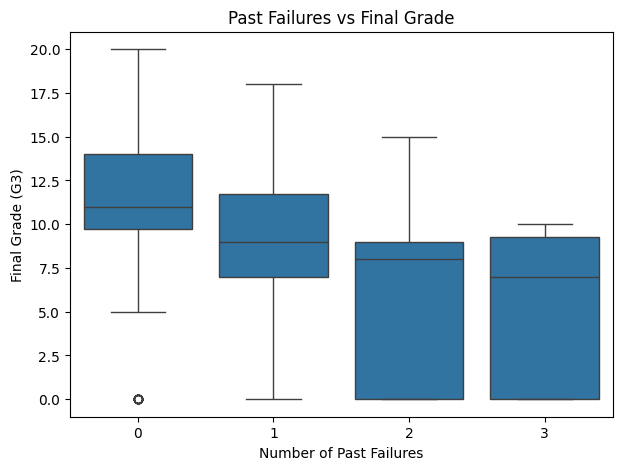

In [9]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='failures', y='G3')

plt.title('Past Failures vs Final Grade')
plt.xlabel('Number of Past Failures')
plt.ylabel('Final Grade (G3)')
plt.show()

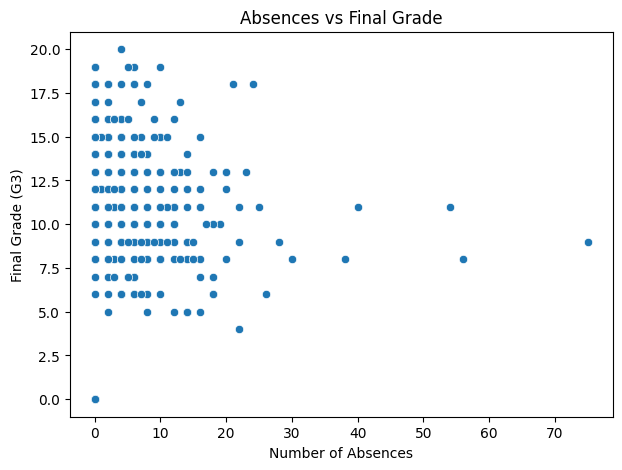

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='absences', y='G3')

plt.title('Absences vs Final Grade')
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade (G3)')
plt.show()


In [11]:
correlation = df.select_dtypes(include='number').corr()

print(correlation['G3'].sort_values(ascending=False))

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


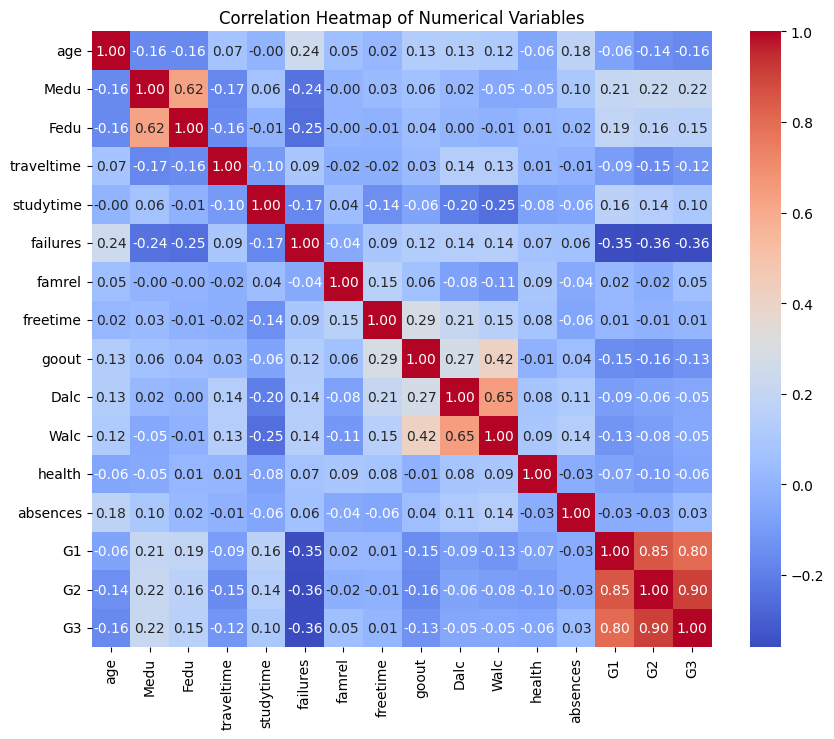

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

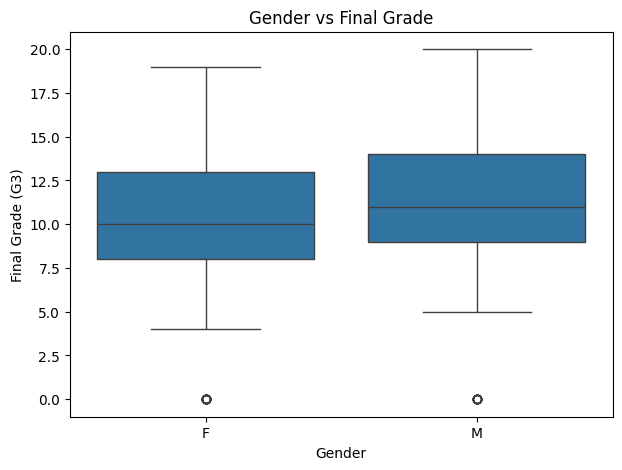

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='sex', y='G3')

plt.title('Gender vs Final Grade')
plt.xlabel('Gender')
plt.ylabel('Final Grade (G3)')
plt.show()

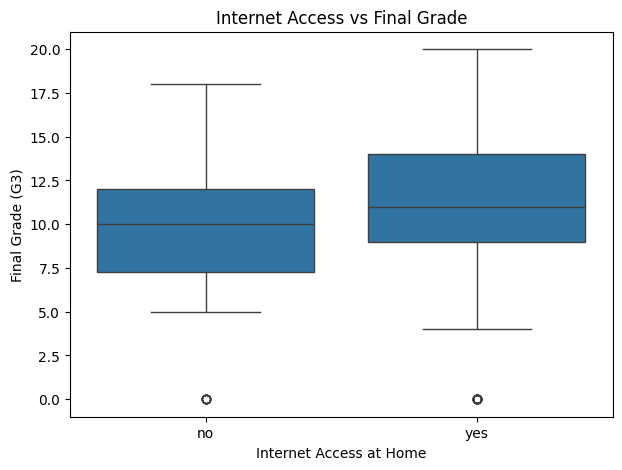

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='internet', y='G3')

plt.title('Internet Access vs Final Grade')
plt.xlabel('Internet Access at Home')
plt.ylabel('Final Grade (G3)')
plt.show()

In [15]:
X = df.drop(columns=['G3', 'G1', 'G2'])
y = df['G3']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (395, 30)
Target shape: (395,)


In [17]:
numeric_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['str']).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (316, 30)
Testing features: (79, 30)
Training target: (316,)
Testing target: (79,)


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

print("Preprocessing libraries imported successfully!")

Preprocessing libraries imported successfully!


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [22]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 3.395260925801919
MSE : 17.60373739832471
RMSE: 4.1956808027213786
R²  : 0.14149247411195798


In [24]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [25]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 2.99379746835443
MSE : 14.068589873417718
RMSE: 3.750811895232513
R²  : 0.31389624761666635


In [26]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Get Random Forest feature importance
importances = rf_model.named_steps['model'].feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                Feature  Importance
12        num__absences    0.189617
5         num__failures    0.144544
11          num__health    0.049260
8            num__goout    0.048252
0              num__age    0.037208
4        num__studytime    0.032455
7         num__freetime    0.028539
3       num__traveltime    0.027659
10            num__Walc    0.025525
2             num__Fedu    0.024657
6           num__famrel    0.024406
1             num__Medu    0.023991
26   cat__Mjob_services    0.017019
39  cat__guardian_other    0.015261
23    cat__Mjob_at_home    0.014849


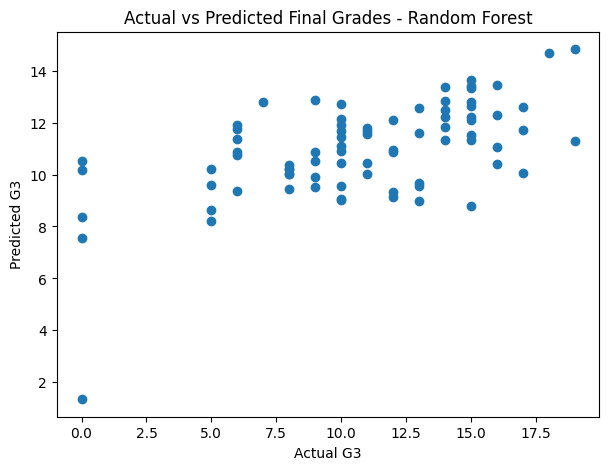

In [27]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades - Random Forest")

plt.show()

In [28]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})

print(comparison)

               Model       MAE        MSE      RMSE        R2
0  Linear Regression  3.395261  17.603737  4.195681  0.141492
1      Random Forest  2.993797  14.068590  3.750812  0.313896


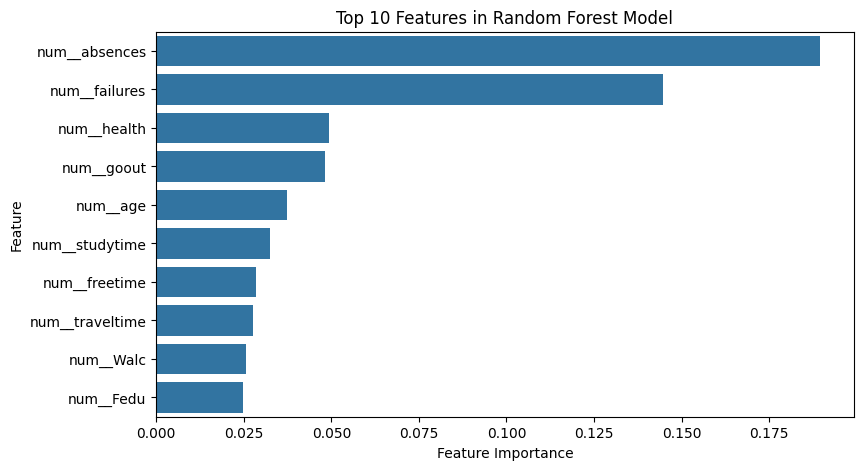

In [29]:
top_features = feature_importance.head(10)

plt.figure(figsize=(9,5))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Features in Random Forest Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()